In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split, KFold
from catboost import CatBoostRegressor

# Data road

In [13]:
base_df = pd.read_excel("A_SPEQT.xlsx")
base_df

,Sample_G,no,Group,Age,Sex,Bedtime9_1,WUT_9,Time_dataset,Insomnia,Hypnotics,...,ISI_total,ISI_G,DBSTq2_av,SPRIS_av,SPAIS_av,SMYTH_av,SMORE_av,SATIS_av,SATIS_G,SATIS_13
0,S2025_006,5031,1,23,2,1,1,1,1,1,...,0,1,1.0,5.000000,5.833333,6.0,5.9,6.000000,6,6
1,S2025_006,10577,2,54,1,1,1,1,1,1,...,3,1,1.5,5.166667,8.000000,5.4,6.0,5.928571,6,6
2,S2025_006,2632,1,33,2,1,0,0,1,1,...,6,1,5.0,4.000000,8.666667,1.1,2.9,4.714286,5,5
3,S2025_006,10684,2,64,2,1,1,1,1,1,...,6,1,9.0,5.833333,9.166667,6.5,9.0,9.357143,10,10
4,S2025_006,16381,2,26,1,1,0,0,1,1,...,7,1,0.5,5.833333,7.666667,2.4,6.3,7.500000,7,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,S2025_006,1837,1,41,1,1,1,1,1,1,...,28,4,10.0,6.333333,8.666667,1.5,3.0,6.785714,7,7
496,S2025_006,10326,2,37,2,1,1,1,1,1,...,28,4,10.0,6.666667,9.333333,7.5,3.7,4.142857,10,10
497,S2025_006,249,1,35,2,1,1,1,1,1,...,28,4,10.0,8.833333,10.000000,5.3,8.9,6.571429,5,5
498,S2025_006,10088,2,37,1,1,1,1,1,1,...,28,4,10.0,8.666667,9.166667,9.2,4.9,2.785714,3,3


# selected item / target

In [18]:
# selected item
selected_items = [
    'SMORE_6',   
    'SPRIS_6',   
    'SMYTH_8',   
    'SPAIS_5',   
    'SATIS_15',  
    'SPRIS_3',   
    'SMYTH_4',   
    'SATIS_5',   
    'SMORE_4',   
    'SPAIS_3',   
    'SPRIS_5', 
    'SATIS_9', 
    'SMYTH_3',   
    'SMORE_8',   
]
# (2) Target variables
target_cols =  [
    "SMORE_av",
    "SPRIS_av",
    "SMYTH_av",
    "SPAIS_av",
    "SATIS_av"
]

X = base_df[selected_items]
y = base_df[target_cols]


# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

best_params = dict(
    loss_function="RMSE",
    iterations=8000,
    learning_rate=0.002887502882062776,
    depth=3,
    l2_leaf_reg=9.576593911651704,
    bagging_temperature=0.03296057975269804,
    random_strength=2.1363388482181613,
    rsm=0.8897141011558393,
    min_data_in_leaf=28,
    random_seed=42,
    early_stopping_rounds=200,
    verbose=False,
    thread_count=-1,
)

# validation


Target Scale    | CV R2      | Test R2    | MSE        | RMSE      
--------------------------------------------------------------------------------
SMORE_av        | 0.8922   | 0.9055   | 0.3658   | 0.6048
SPRIS_av        | 0.8559   | 0.8174   | 0.3535   | 0.5945
SMYTH_av        | 0.8682   | 0.9265   | 0.3353   | 0.5790
SPAIS_av        | 0.8791   | 0.8855   | 0.4285   | 0.6546
SATIS_av        | 0.8548   | 0.8332   | 0.4037   | 0.6354
--------------------------------------------------------------------------------
Mean Score      | 0.8700   | 0.8736   | 0.3774   | 0.6137


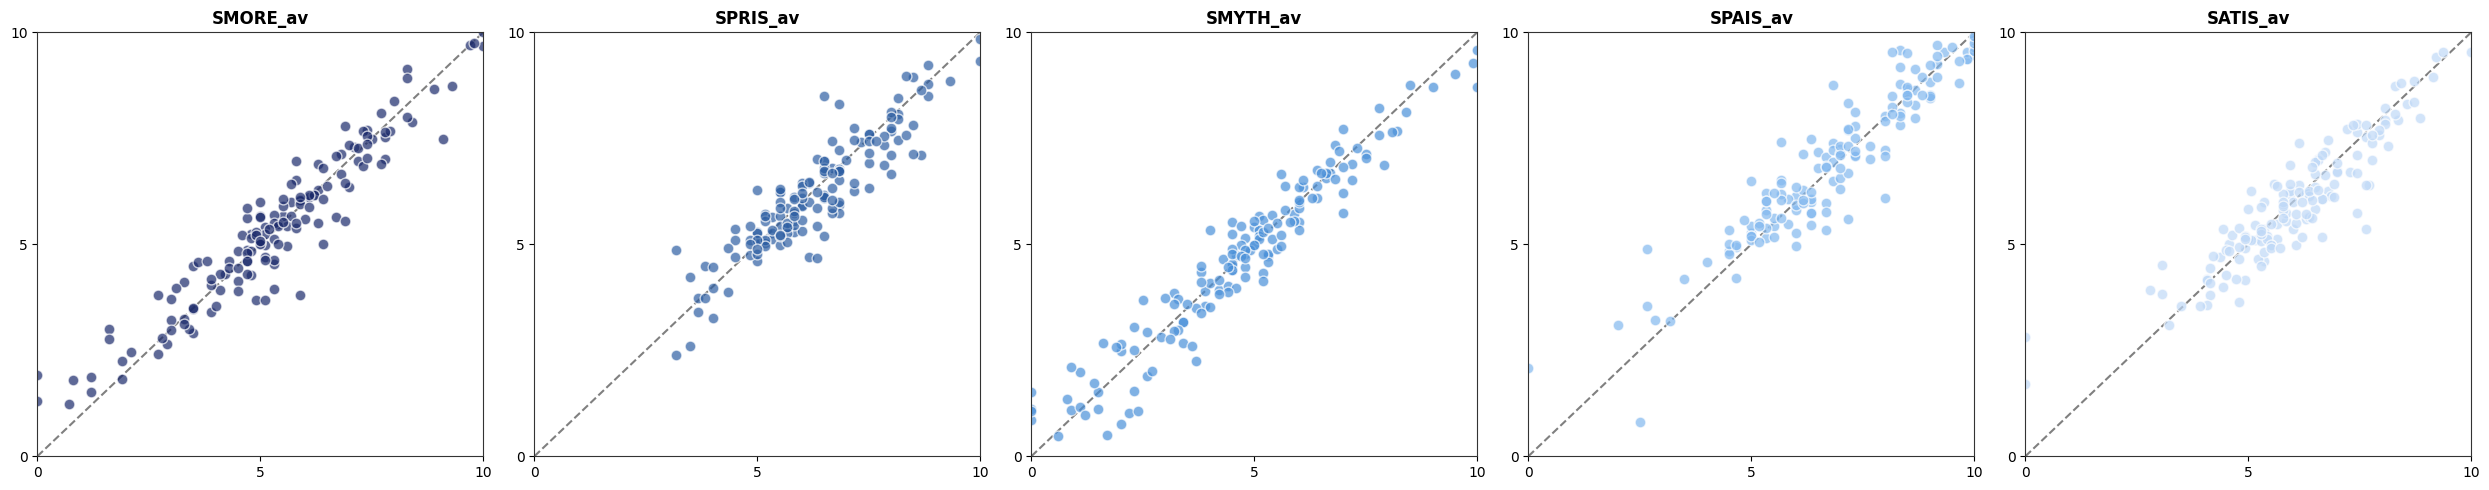

In [19]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

navy_to_blue = [
    "#1b2a6b",
    "#2e5fa3",
    "#4a90d9",
    "#82b8ef",
    "#c0d9f7"
]

n_targets = len(target_cols)

fig, axes = plt.subplots(
    1,
    n_targets,
    figsize=(5 * n_targets, 5)
)

if n_targets == 1:
    axes = [axes]

print("\n" + "=" * 80)

print(
    f"{'Target Scale':<15} | "
    f"{'CV R2':<10} | "
    f"{'Test R2':<10} | "
    f"{'MSE':<10} | "
    f"{'RMSE':<10}"
)

print("-" * 80)

test_metrics = []

for i, t in enumerate(target_cols):

    fold_val_r2 = []

    for train_idx, val_idx in kf.split(X_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train[t].iloc[train_idx]
        y_val = y_train[t].iloc[val_idx]

        cv_model = CatBoostRegressor(**best_params)

        cv_model.fit(
            X_tr,
            y_tr,
            verbose=False
        )

        val_preds = cv_model.predict(X_val)

        fold_val_r2.append(
            r2_score(y_val, val_preds)
        )

    cv_r2 = np.mean(fold_val_r2)

    final_model = CatBoostRegressor(**best_params)

    final_model.fit(
        X_train,
        y_train[t],
        verbose=False
    )

    test_preds = final_model.predict(X_test)

    test_r2 = r2_score(
        y_test[t],
        test_preds
    )

    test_mse = mean_squared_error(
        y_test[t],
        test_preds
    )

    test_rmse = np.sqrt(test_mse)

    test_metrics.append([
        cv_r2,
        test_r2,
        test_mse,
        test_rmse
    ])

    print(
        f"{t:<15} | "
        f"{cv_r2:.4f}   | "
        f"{test_r2:.4f}   | "
        f"{test_mse:.4f}   | "
        f"{test_rmse:.4f}"
    )

    ax = axes[i]

    current_color = (
        navy_to_blue[i]
        if i < len(navy_to_blue)
        else "#3498db"
    )

    ax.scatter(
        y_test[t],
        test_preds,
        alpha=0.7,
        color=current_color,
        edgecolors="white",
        s=60,
        zorder=2
    )

    ax.plot(
        [0, 10],
        [0, 10],
        color="gray",
        linestyle="--",
        linewidth=1.5,
        zorder=1
    )

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)

    ax.set_xticks([0, 5, 10])
    ax.set_yticks([0, 5, 10])

    ax.set_title(
        t,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_facecolor("none")
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")

fig.patch.set_facecolor("none")

avg_metrics = np.mean(
    test_metrics,
    axis=0
)

print("-" * 80)

print(
    f"{'Mean Score':<15} | "
    f"{avg_metrics[0]:.4f}   | "
    f"{avg_metrics[1]:.4f}   | "
    f"{avg_metrics[2]:.4f}   | "
    f"{avg_metrics[3]:.4f}"
)

print("=" * 80)

plt.tight_layout()

plt.savefig(
    "scatterplot_final.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

# robustness check

In [22]:
results = []

for i in range(1000):

    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=i
    )

    for t in target_cols:

        model = CatBoostRegressor(**best_params)

        model.fit(
            X_tr,
            y_tr[t],
            verbose=False
        )

        test_preds = model.predict(X_te)

        test_r2 = r2_score(
            y_te[t],
            test_preds
        )

        test_mse = mean_squared_error(
            y_te[t],
            test_preds
        )

        test_rmse = np.sqrt(test_mse)

        results.append({
            "iteration": i + 1,
            "target": t,
            "r2": test_r2,
            "mse": test_mse,
            "rmse": test_rmse
        })

    if (i + 1) % 10 == 0:
        print(f"Run: {i + 1}/1000")


df_robust = pd.DataFrame(results)


summary = (
    df_robust
    .groupby("target")[["r2", "mse", "rmse"]]
    .agg(["mean", "std"])
    .round(4)
)

print("\n" + "=" * 70)
print("Robustness Analysis Summary (1000 repetitions)")
print("=" * 70)

print(summary.to_string())

print("=" * 70)


df_robust.to_csv(
    "robustness_results.csv",
    index=False
)

Run: 10/1000
Run: 20/1000
Run: 30/1000
Run: 40/1000
Run: 50/1000
Run: 60/1000
Run: 70/1000
Run: 80/1000
Run: 90/1000
Run: 100/1000
Run: 110/1000
Run: 120/1000
Run: 130/1000
Run: 140/1000
Run: 150/1000
Run: 160/1000
Run: 170/1000
Run: 180/1000
Run: 190/1000
Run: 200/1000
Run: 210/1000
Run: 220/1000
Run: 230/1000
Run: 240/1000
Run: 250/1000
Run: 260/1000
Run: 270/1000
Run: 280/1000
Run: 290/1000
Run: 310/1000
Run: 390/1000
Run: 400/1000
Run: 410/1000
Run: 420/1000
Run: 430/1000
Run: 440/1000
Run: 450/1000
Run: 460/1000
Run: 470/1000
Run: 480/1000
Run: 490/1000
Run: 500/1000
Run: 510/1000
Run: 520/1000
Run: 530/1000
Run: 540/1000
Run: 550/1000
Run: 560/1000
Run: 570/1000
Run: 580/1000
Run: 590/1000
Run: 600/1000
Run: 610/1000
Run: 630/1000
Run: 640/1000
Run: 650/1000
Run: 660/1000
Run: 670/1000
Run: 680/1000
Run: 690/1000
Run: 710/1000
Run: 720/1000
Run: 780/1000
Run: 790/1000
Run: 800/1000
Run: 810/1000
Run: 820/1000
Run: 830/1000
Run: 840/1000
Run: 850/1000
Run: 860/1000
Run: 870/1000
R

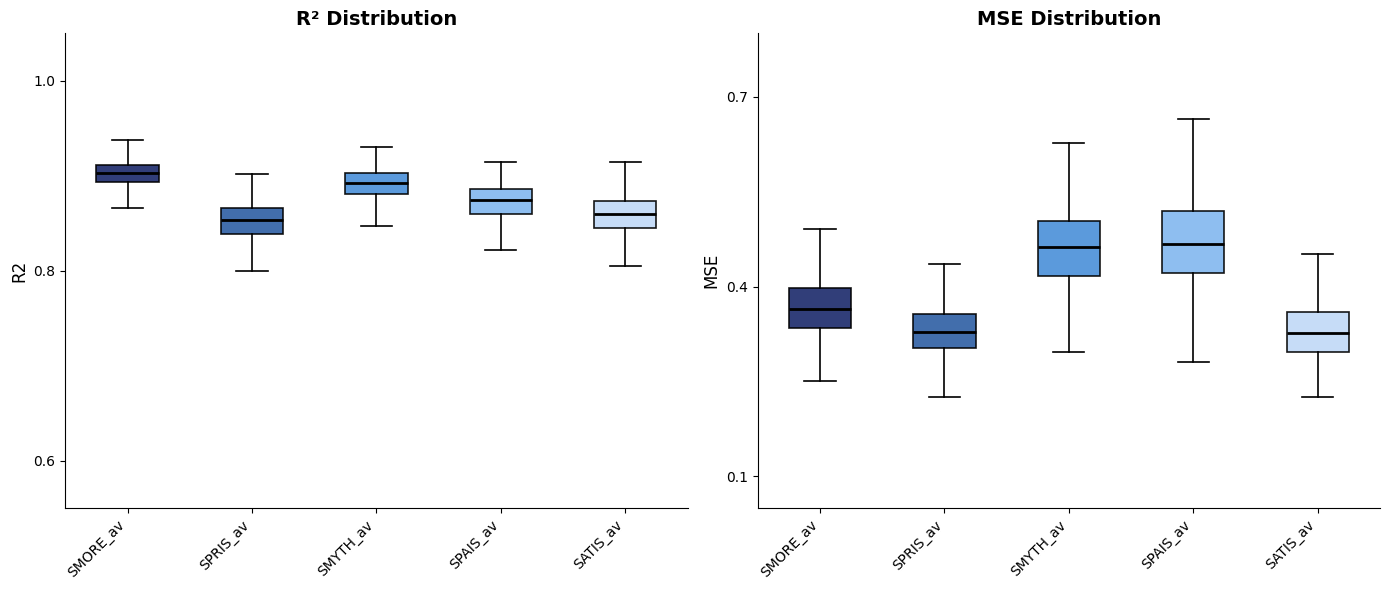

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sorted_targets = [
    'SMORE_av',
    'SPRIS_av',
    'SMYTH_av',
    'SPAIS_av',
    'SATIS_av'
]

navy_to_blue = [
    '#1b2a6b',
    '#2e5fa3',
    '#4a90d9',
    '#82b8ef',
    '#c0d9f7'
]

color_map = {
    t: navy_to_blue[i]
    for i, t in enumerate(sorted_targets)
}

metrics = ['r2', 'mse']
titles = ['R² Distribution', 'MSE Distribution']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, metric in enumerate(metrics):

    data_to_plot = [
        df_robust[df_robust['target'] == t][metric]
        for t in sorted_targets
    ]

    bp = axes[idx].boxplot(
        data_to_plot,
        tick_labels=sorted_targets,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=2),
        boxprops=dict(linewidth=1.2),
        whiskerprops=dict(color='black', linewidth=1.2),
        capprops=dict(color='black', linewidth=1.2)
    )

    for patch, t in zip(bp['boxes'], sorted_targets):
        patch.set_facecolor(color_map[t])
        patch.set_edgecolor('black')
        patch.set_alpha(0.9)

    axes[idx].set_title(
        titles[idx],
        fontsize=14,
        fontweight='bold'
    )

    axes[idx].set_ylabel(
        metric.upper(),
        fontsize=12
    )

    if metric == 'r2':
        axes[idx].set_ylim(0.55, 1.05)
        axes[idx].set_yticks([0.6, 0.8, 1.0])
    else:
        axes[idx].set_ylim(0.05, 0.8)
        axes[idx].set_yticks([0.1, 0.4, 0.7])

    axes[idx].grid(False)
    axes[idx].set_facecolor('none')
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

    for tick in axes[idx].get_xticklabels():
        tick.set_rotation(45)
        tick.set_ha('right')

fig.patch.set_facecolor('none')

plt.tight_layout()

plt.savefig(
    "boxplot_robustness.png",
    dpi=300,
    transparent=True,
    bbox_inches='tight'
)

plt.show()